In [ ]:
import os
import obspy
import numpy as np
from tqdm import tqdm

def batch_convert_mseed_to_npy(root_dir, output_root):
    # Menelusuri semua folder secara rekursif
    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if file.endswith(".mseed"):
                mseed_path = os.path.join(root, file)
                
                # Menentukan folder output agar struktur tetap terjaga
                relative_path = os.path.relpath(root, root_dir)
                save_dir = os.path.join(output_root, relative_path)
                if not os.path.exists(save_dir):
                    os.makedirs(save_dir)
                
                try:
                    # 1. Baca mseed
                    st = obspy.read(mseed_path)
                    tr = st.select(component='Z')[0] # Ambil komponen Z
                    
                    # 2. Pre-processing sesuai standar Zhi Geng
                    tr.detrend('linear')
                    tr.resample(100.0) # Resample ke 100 Hz
                    
                    # 3. Sliding Window 7 detik (700 sampel)
                    data = tr.data
                    window_size = 700
                    
                    # Proses per segmen 7 detik
                    for i in range(0, len(data) - window_size, 100): # step 100
                        window = data[i:i+window_size]
                        max_val = np.max(np.abs(window))
                        if max_val > 0:
                            window = window / max_val
                            
                        # Simpan ke .npy
                        file_name = f"{os.path.splitext(file)[0]}_seg_{i}.npy"
                        np.save(os.path.join(save_dir, file_name), window)
                        
                except Exception as e:
                    print(f"Gagal memproses {mseed_path}: {e}")

# PATH ANDA
ROOT_DIR = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready"
OUTPUT_DIR = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_npy_ready"

print("🚀 Memulai konversi batch...")
batch_convert_mseed_to_npy(ROOT_DIR, OUTPUT_DIR)
print(f"✅ Selesai! Semua data telah dikonversi ke {OUTPUT_DIR}")

In [ ]:
# Jalankan skrip ini untuk evaluasi akhir pada dataset Indonesia Anda
import glob
import numpy as np
from tqdm import tqdm

# Update path ke folder npy yang baru saja dibuat
npy_folder = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_npy_ready"
all_npy_files = glob.glob(os.path.join(npy_folder, '**', '*.npy'), recursive=True)

# Lakukan evaluasi per segmen dan kumpulkan hasilnya
# ... (Gunakan fungsi sliding_window_inference atau loop evaluasi yang sebelumnya telah kita perbaiki dengan threshold 0.2)

In [ ]:
import os
import glob
import numpy as np
import tensorflow as tf
from tensorflow import keras
from Library import utils, dataset

# 1. SETUP PATHS
BASE_REP = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo'
MODEL_PATH = os.path.join(BASE_REP, 'Pre-trained model/MCU-Quake 5-20')
EMB_DIR = os.path.join(BASE_REP, 'Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909')

# 2. LOAD MODEL & PDFS (Penting: harus dilakukan sekali saja di awal)
model = keras.models.load_model(MODEL_PATH, compile=False)
emb_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
pdfs_Z = utils.embedding_PDFs_1D(emb_Z)

# 3. DEBUGGING PADA 10 FILE
npy_folder = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_npy_ready"
all_files = glob.glob(os.path.join(npy_folder, '**', '*.npy'), recursive=True)

print(f"🔍 Mencoba inferensi pada 10 file pertama dari total {len(all_files)}...")

for f in all_files[:10]:
    data = np.load(f)
    if data.shape[0] == 700:
        emb_z = utils.latent_codes_1D(data.astype(np.float32).reshape(1, -1), model)
        _, score, _ = utils.infer_1C_PDFs(emb_z, pdfs_Z, "Kernel")
        print(f"File: {os.path.basename(f)} | Skor 'le': {score.get('le', 0)}")
    else:
        print(f"Skipping: {os.path.basename(f)} - Shape salah: {data.shape}")

In [ ]:
import os
import glob

# Ganti dengan path folder npy Anda
npy_folder = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_npy_ready"
sample_files = glob.glob(os.path.join(npy_folder, '**', '*.npy'), recursive=True)[:5]

print("Contoh nama file di folder Anda:")
for f in sample_files:
    print(os.path.basename(f))

In [ ]:
import pandas as pd
import os
import glob

# 1. Load Katalog
# Ganti dengan path lengkap ke file katalog Anda
KATALOG_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon_buffer2deg.csv'
#KATALOG_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/katalog_gabungan_final_mcu.csv'
# 1. Load Katalog dengan path lengkap
katalog = pd.read_csv(KATALOG_PATH) 

# Pastikan nama kolomnya benar-benar 'EventCode'
# 1. Gunakan kolom 'id' sebagai kunci unik kejadian
event_codes_valid = set(katalog['id'].astype(str))

# 2. Fungsi filter yang disesuaikan
def is_gempa(filename, valid_codes):
    # Pola file: GE_UGM_usb000k137_seg_22200.npy
    # Bagian ke-2 setelah split('_') adalah 'usb000k137'
    parts = filename.split('_')
    if len(parts) >= 3:
        event_code = parts[2] 
        return event_code in valid_codes
    return False

# 3. Jalankan filtering
print("🚀 Memulai filtering berdasarkan kolom 'id'...")
target_files = [f for f in all_files if is_gempa(os.path.basename(f), event_codes_valid)]

print(f"✅ Ditemukan {len(target_files)} segmen yang relevan dengan katalog BMKG.")

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import glob
import random
from tqdm import tqdm
from Library import utils, dataset
from tensorflow import keras

# 1. SETUP PATHS
BASE_REP = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo'
MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909")
KATALOG_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon_buffer2deg.csv'
NPY_FOLDER = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_npy_ready"
OUTPUT_PATH = "hasil_inferensi_final_65k.json"

# 2. LOAD MODEL & DATA STATISTIK
print("Loading model dan statistik embedding...")
model = keras.models.load_model(MODEL_PATH, compile=False)
emb_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
pdfs_Z = utils.embedding_PDFs_1D(emb_Z)

# 3. FILTERING & SAMPLING
print("Memuat katalog dan memfilter file...")
katalog = pd.read_csv(KATALOG_PATH)
valid_ids = set(katalog['id'].astype(str))

all_files = glob.glob(os.path.join(NPY_FOLDER, '**', '*.npy'), recursive=True)

target_files = [f for f in all_files if os.path.basename(f).split('_')[2] in valid_ids]

# Skala Zhi Geng (65.000)
target_scale = 65000
if len(target_files) > target_scale:
    target_files = random.sample(target_files, target_scale)
    print(f"✅ Data disesuaikan ke skala {target_scale} segmen.")

# 4. INFERENSI DENGAN CHECKPOINTING
results = []
if os.path.exists(OUTPUT_PATH):
    with open(OUTPUT_PATH, "r") as f:
        results = json.load(f)

processed_files = {r['file'] for r in results}
files_to_process = [f for f in target_files if os.path.basename(f) not in processed_files]

print(f"🚀 Memulai inferensi pada {len(files_to_process)} file...")

for i, f in enumerate(tqdm(files_to_process)):
    try:
        data = np.load(f)
        if data.shape[0] == 700:
            emb_z = utils.latent_codes_1D(data.astype(np.float32).reshape(1, -1), model)
            _, score, _ = utils.infer_1C_PDFs(emb_z, pdfs_Z, "Kernel")
            results.append({"file": os.path.basename(f), "score_le": float(score.get('le', 0))})
            
            if (i + 1) % 5000 == 0:
                with open(OUTPUT_PATH, "w") as j:
                    json.dump(results, j)
    except Exception:
        continue

with open(OUTPUT_PATH, "w") as j:
    json.dump(results, j)
print(f"✅ Inferensi selesai! Hasil di {OUTPUT_PATH}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data hasil inferensi
df = pd.read_json("/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/hasil_inferensi_final_65k.json")

# Visualisasi
plt.figure(figsize=(10, 6))
sns.histplot(df['score_le'], bins=50, kde=True, color='teal')
plt.title('Distribusi Skor Local Earthquake (le) pada Dataset Indonesia')
plt.xlabel('Skor Inferensi (MCU-Quake)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', alpha=0.3)
plt.savefig("distribusi_skor_inferensi.png")
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# 1. Load data
df_results = pd.read_json('/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/hasil_inferensi_final_65k.json')
df_katalog = pd.read_csv('/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon_buffer2deg.csv')

# 2. Persiapan Label (Asumsi: File dengan ID di katalog = 'Gempa', sisanya 'Noise')
# Kita perlu mencocokkan ID dari nama file hasil inferensi dengan katalog
def get_label(filename):
    event_id = filename.split('_')[2]
    return 1 if event_id in set(df_katalog['id'].astype(str)) else 0

df_results['true_label'] = df_results['file'].apply(get_label)

# 3. Tentukan Prediksi berdasarkan Threshold
threshold = 1.0
df_results['pred_label'] = (df_results['score_le'] > threshold).astype(int)

# 4. Hitung Metrik
cm = confusion_matrix(df_results['true_label'], df_results['pred_label'])
report = classification_report(df_results['true_label'], df_results['pred_label'], target_names=['Noise', 'Gempa'])

print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)

In [ ]:
import os
import glob
import numpy as np
import random
import pandas as pd

# 1. SETUP
NPY_FOLDER = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_npy_ready"
KATALOG_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon_buffer2deg.csv'

# 2. LOAD ID GEMPA (Untuk memastikan Noise tidak terkontaminasi gempa)
katalog = pd.read_csv(KATALOG_PATH)
valid_ids = set(katalog['id'].astype(str))

# 3. IDENTIFIKASI NOISE
all_files = glob.glob(os.path.join(NPY_FOLDER, '**', '*.npy'), recursive=True)

# File yang BUKAN merupakan gempa
noise_files = [f for f in all_files if os.path.basename(f).split('_')[2] not in valid_ids]

# 4. SAMPLING NOISE (Sesuai jumlah data gempa Zhi Geng)
# Mengambil jumlah yang seimbang dengan data gempa Anda (65.000)
noise_sample = random.sample(noise_files, 65000)

print(f"✅ Berhasil menyusun {len(noise_sample)} segmen noise untuk validasi.")

In [ ]:
import os
import glob
import numpy as np
import random
import pandas as pd
from tqdm import tqdm

# 1. KONFIGURASI PATH
NPY_FOLDER = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_npy_ready"
OUTPUT_NOISE_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_npy_noise'
KATALOG_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon_buffer2deg.csv'

# Pastikan folder output ada
os.makedirs(OUTPUT_NOISE_DIR, exist_ok=True)

# 2. LOAD DATA GEMPA (Untuk filter agar tidak ada gempa masuk ke dataset noise)
print("Memuat katalog untuk identifikasi data noise...")
katalog = pd.read_csv(KATALOG_PATH)
valid_ids = set(katalog['id'].astype(str))

# 3. IDENTIFIKASI DAN SALIN FILE NOISE
all_files = glob.glob(os.path.join(NPY_FOLDER, '**', '*.npy'), recursive=True)

# Memfilter file yang bukan merupakan gempa
noise_files = [f for f in all_files if os.path.basename(f).split('_')[2] not in valid_ids]

# 4. SAMPLING NOISE (Target 65.000 agar setara dengan data gempa Anda)
target_count = 65000
if len(noise_files) > target_count:
    noise_sample = random.sample(noise_files, target_count)
else:
    noise_sample = noise_files

print(f"🚀 Menyalin {len(noise_sample)} file noise ke direktori target...")

# Proses penyalinan (menggunakan shutil untuk memindahkan file)
import shutil
for f in tqdm(noise_sample):
    dest_path = os.path.join(OUTPUT_NOISE_DIR, os.path.basename(f))
    shutil.copy2(f, dest_path)

print(f"✅ Dataset Noise berhasil disusun di: {OUTPUT_NOISE_DIR}")

In [ ]:
# -*- coding: utf-8 -*-
import os
import json
import numpy as np
import glob
import random
import logging
from datetime import datetime
from tqdm import tqdm
from Library import utils, dataset
from tensorflow import keras

if __name__ == "__main__":
    # 1. KONFIGURASI PATH
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/rep_code"
    MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
    EMB_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, STEAD norm7 mag3 L n61099, 30172538'
    
    GEMPA_DIR = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_npy_ready"
    NOISE_DIR = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_npy_noise"
    SAVE_BASE = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output'
    
    # Setup Direktori Hasil
    os.makedirs(SAVE_BASE, exist_ok=True)
    time_str = datetime.now().strftime("%d%H%M%S")
    save_dir = os.path.join(SAVE_BASE, f"IndoBench_{time_str}")
    os.makedirs(save_dir, exist_ok=True)

    # Logging
    logging.basicConfig(filename=os.path.join(save_dir, "task_log_indo.txt"), level=logging.INFO, 
                        filemode='w', format='%(asctime)s - [%(levelname)s]: %(message)s')
    logger = logging.getLogger()
    logger.addHandler(logging.StreamHandler())

    # 2. LOAD MODEL & STATISTIK
    logger.info("Loading model dan statistik embedding...")
    model = keras.models.load_model(MODEL_PATH, compile=False)
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embeddings_Z_PDFs = utils.embedding_PDFs_1D(embedding_Z)

    # 3. PERSIAPAN DATA (65k Gempa + 65k Noise)
    logger.info("Menyiapkan daftar file untuk inferensi...")
    files_gempa = glob.glob(os.path.join(GEMPA_DIR, '**', '*.npy'), recursive=True)
    files_noise = glob.glob(os.path.join(NOISE_DIR, '**', '*.npy'), recursive=True)

    data_to_infer = [(f, 1) for f in files_gempa[:65000]] + [(f, 0) for f in files_noise[:65000]]
    random.shuffle(data_to_infer)


    # 4. INFERENSI (Versi Debugging)
    logger.info("Memulai inferensi dengan pengecekan data...")
    
    for file_path, label in tqdm(data_to_infer, desc="Inference Indonesia Data"):
        try:
            data = np.load(file_path).astype(np.float32)
            
            # Pastikan data memiliki panjang 700
            if data.shape[0] == 700:
                data_in = data.reshape(1, -1)
                
                # Latent Encoding
                emb_z = utils.latent_codes_1D(data_in, model)
                
                # Inferensi
                _, score, _ = utils.infer_1C_PDFs(emb_z, embeddings_Z_PDFs, "Kernel")
                
                # Ambil skor 'le'
                score_val = float(score.get('le', 0))
                
                # Masukkan ke list
                total_true.append(label)
                total_pred.append(1 if score_val >= 1.0 else 0)
            else:
                logger.warning(f"File {file_path} dilewati: Shape {data.shape}")
                
        except Exception as e:
            logger.error(f"Error pada file {file_path}: {e}")
            continue

    # 5. METRICS & PLOT (Format sesuai skrip STEAD Anda)
    matrix, metrics = utils.calc_confusion_metrics(total_true, total_pred)
    
    # Plotting
    fig = utils.plot_confusion("Indonesia Dataset Benchmarking", ["Noise", "Gempa"], matrix, metrics)
    fig.savefig(os.path.join(save_dir, "Indonesia_Matrix.jpg"), dpi=300)
    
    # Save Metrics
    dataset.save_json_data(os.path.join(save_dir, "indo_metrics.json"), metrics)
    
    # Final Log
    logger.info("\n" + "="*40)
    logger.info(f"INDONESIA DATA ACCURACY: {metrics.get('accuracy (avg.)')}")
    logger.info(f"INDONESIA DATA F1-SCORE: {metrics.get('f1-score (avg.)')}")
    logger.info("="*40)

In [ ]:
# Cek isi list sebelum masuk ke fungsi utils
print(f"Total True labels: {len(total_true)}")
print(f"Total Pred labels: {len(total_pred)}")
print(f"Unique true values: {set(total_true)}")
print(f"Unique pred values: {set(total_pred)}")

# Jika hasil Unique pred values hanya [0] atau hanya [1], 
# berarti model Anda memprediksi SEMUA data sebagai satu kelas saja.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
import glob

# 1. BUAT MAP PATH LENGKAP (Indexing semua file npy)
print("Mengindeks semua file npy...")
all_npy_files = glob.glob(os.path.join(GEMPA_DIR, '**', '*.npy'), recursive=True)
path_map = {os.path.basename(f): f for f in all_npy_files}

# 2. LOAD HASIL
with open("hasil_inferensi_gabungan_130k.json", "r") as f:
    results = json.load(f)

# 3. FILTER & SORT
gempa_results = [r for r in results if r['true_label'] == 1]
gempa_results.sort(key=lambda x: x['score_le'], reverse=True)

# 4. PLOT TOP 5
plt.figure(figsize=(15, 10))
for i in range(min(5, len(gempa_results))):
    file_name = gempa_results[i]['file']
    score = gempa_results[i]['score_le']
    
    # Ambil path dari map yang sudah dibuat
    file_path = path_map.get(file_name)
    
    if file_path and os.path.exists(file_path):
        data = np.load(file_path)
        plt.subplot(5, 1, i+1)
        plt.plot(data, color='black', linewidth=0.8)
        plt.title(f"Rank {i+1} | Score: {score:.4f} | File: {file_name}")
        plt.grid(True, alpha=0.3)
    else:
        print(f"File tidak ditemukan: {file_name}")

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Cek spektrum frekuensi
data = np.load(file_path) # Gunakan file Rank 1 tadi
freqs = np.fft.rfftfreq(len(data), d=1/100) # d=0.01s (100Hz)
fft_vals = np.abs(np.fft.rfft(data))

plt.figure(figsize=(10, 4))
plt.plot(freqs, fft_vals)
plt.title("Analisis Spektrum Frekuensi")
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Amplitudo")
plt.grid(True)
plt.show()

In [1]:
import pandas as pd

# Load katalog
katalog = pd.read_csv('/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon_buffer2deg.csv')

# Tampilkan 5 baris pertama dan info kolomnya
print(katalog.head())
print(katalog.columns)

                       time  latitude  longitude  depth  mag magType   nst  \
0  2001-01-01T12:44:31.220Z    -0.240    134.961   33.0  5.0      mb  12.0   
1  2001-01-02T17:21:54.440Z    -9.009    122.471   33.0  4.5      mb   8.0   
2  2001-01-04T03:50:11.440Z    -8.403    108.374   33.0  5.3      mb  46.0   
3  2001-01-04T15:26:56.130Z    -5.875    103.224   33.0  4.7      mb  13.0   
4  2001-01-07T09:36:31.020Z    -5.253    133.436   33.0  4.7      mb  19.0   

   gap  dmin   rms  ...                              place        type  \
0  NaN   NaN  1.08  ...  121 km NE of Manokwari, Indonesia  earthquake   
1  NaN   NaN  0.67  ...    51 km SSE of Maumere, Indonesia  earthquake   
2  NaN   NaN  1.01  ...  111 km SSW of Sidareja, Indonesia  earthquake   
3  NaN   NaN  0.81  ...  204 km S of Pagar Alam, Indonesia  earthquake   
4  NaN   NaN  1.24  ...       86 km ENE of Tual, Indonesia  earthquake   

  horizontalError depthError magError  magNst    status  locationSource  \
0          

In [7]:
import os
import pandas as pd
import numpy as np
from obspy import UTCDateTime, read
from tqdm import tqdm
from scipy.signal import detrend, butter, filtfilt

# --- KONFIGURASI ---
CATALOG_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon_buffer2deg.csv'
MSEED_ROOT = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready'
OUTPUT_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/earthquake_npy_ready'

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# --- FUNGSI PREPROCESSING ---
def zhi_geng_preprocess(data, fs=100):
    data = detrend(data - np.mean(data))
    nyq = 0.5 * fs
    b, a = butter(4, [1.0/nyq, 20.0/nyq], btype='band')
    data = filtfilt(b, a, data)
    max_val = np.max(np.abs(data))
    return data / max_val if max_val > 0 else data

# --- PROSES UTAMA ---
katalog = pd.read_csv(CATALOG_PATH)
print(f"🚀 Memproses {len(katalog)} event dari katalog...")

for _, row in tqdm(katalog.iterrows(), total=len(katalog)):
    try:
        event_id = str(row['id'])
        t_event = UTCDateTime(row['time'])
        year = str(t_event.year)
        
        # Lokasi target berdasarkan struktur folder: ROOT/TAHUN/EVENT_ID
        event_dir = os.path.join(MSEED_ROOT, year, event_id)
        
        if not os.path.exists(event_dir):
            continue
            
        # Cari file .mseed di dalam folder event tersebut
        mseed_files = [f for f in os.listdir(event_dir) if f.endswith('.mseed')]
        
        for mseed_file in mseed_files:
            st = read(os.path.join(event_dir, mseed_file))
            st.resample(100.0)
            
            # Potong (2 detik sebelum hingga 5 detik sesudah)
            st.trim(t_event - 2, t_event + 5)
            
            for tr in st:
                if tr.stats.channel.endswith('Z') and len(tr.data) >= 700:
                    data_clean = zhi_geng_preprocess(tr.data[:700], fs=100)
                    
                    save_path = os.path.join(OUTPUT_DIR, f"{event_id}_{tr.stats.station}_seg.npy")
                    np.save(save_path, data_clean.astype(np.float32))
                    
    except Exception as e:
        # print(f"Error pada event {row['id']}: {e}") # Aktifkan jika butuh debug
        continue

print("✅ Selesai! Data seismik telah dipotong dan dibersihkan dari struktur direktori.")

🚀 Memproses 12722 event dari katalog...


100%|██████████| 12722/12722 [02:04<00:00, 102.50it/s]

✅ Selesai! Data seismik telah dipotong dan dibersihkan dari struktur direktori.


In [9]:
import os
import pandas as pd
import numpy as np
from obspy import UTCDateTime, read
from tqdm import tqdm
from scipy.signal import detrend, butter, filtfilt

# --- KONFIGURASI ---
CATALOG_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon_buffer2deg.csv'
MSEED_ROOT = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready'
OUTPUT_NOISE_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/noise_npy_ready'
BUFFER_SEC = 600  # Jarak aman 10 menit

if not os.path.exists(OUTPUT_NOISE_DIR): os.makedirs(OUTPUT_NOISE_DIR)

# --- FUNGSI PREPROCESSING ---
def zhi_geng_preprocess(data, fs=100):
    data = detrend(data - np.mean(data))
    nyq = 0.5 * fs
    b, a = butter(4, [1.0/nyq, 20.0/nyq], btype='band')
    data = filtfilt(b, a, data)
    max_val = np.max(np.abs(data))
    return data / max_val if max_val > 0 else data

# --- LOAD DAN PROSES KATALOG ---
katalog = pd.read_csv(CATALOG_PATH)
katalog['t_event'] = katalog['time'].apply(UTCDateTime)
event_times = katalog['t_event'].values

print("🚀 Memulai ekstraksi Noise tervalidasi (Filtering gempa aktif)...")

# --- SCAN DAN EKSTRAKSI ---
for root, dirs, files in os.walk(MSEED_ROOT):
    for file in files:
        if file.endswith('.mseed'):
            try:
                st = read(os.path.join(root, file))
                st.resample(100.0)
                
                for tr in st:
                    if tr.stats.channel.endswith('Z'):
                        # Cek segmen data per 7 detik
                        for t_start in np.arange(tr.stats.starttime.timestamp, 
                                                tr.stats.endtime.timestamp - 7, 20):
                            
                            t_window = UTCDateTime(t_start)
                            
                            # Validasi: Apakah window ini aman dari gempa?
                            if all(abs(t_window - t_event) > BUFFER_SEC for t_event in event_times):
                                data_segment = tr.slice(t_window, t_window + 7).data
                                if len(data_segment) >= 700:
                                    data_clean = zhi_geng_preprocess(data_segment[:700])
                                    
                                    # Simpan sebagai noise tervalidasi
                                    fname = f"noise_{tr.stats.station}_{int(t_window.timestamp)}.npy"
                                    np.save(os.path.join(OUTPUT_NOISE_DIR, fname), data_clean.astype(np.float32))
            except Exception:
                continue

print("✅ Ekstraksi Noise tervalidasi selesai!")

🚀 Memulai ekstraksi Noise tervalidasi (Filtering gempa aktif)...


KeyboardInterrupt: 

In [10]:
import os
import random
import shutil

# Konfigurasi Path
NOISE_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/noise_npy_ready'
GEMPA_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/earthquake_npy_ready'
BALANCED_NOISE_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/noise_balanced'

if not os.path.exists(BALANCED_NOISE_DIR): os.makedirs(BALANCED_NOISE_DIR)

# Hitung jumlah target
target_count = len(os.listdir(GEMPA_DIR))
all_noise_files = os.listdir(NOISE_DIR)

print(f"⚖️ Menyeimbangkan Noise... Target: {target_count} file.")

# Ambil sampel acak
selected_noise = random.sample(all_noise_files, target_count)

# Salin file ke folder baru
for filename in selected_noise:
    shutil.copy(os.path.join(NOISE_DIR, filename), os.path.join(BALANCED_NOISE_DIR, filename))

print(f"✅ Selesai! Dataset sekarang seimbang dengan {len(os.listdir(BALANCED_NOISE_DIR))} file noise.")

⚖️ Menyeimbangkan Noise... Target: 16469 file.
✅ Selesai! Dataset sekarang seimbang dengan 16469 file noise.


In [11]:
import json
import glob
import os
import random

# Path
GEMPA_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/earthquake_npy_ready'
NOISE_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/noise_npy_ready'
OUTPUT_FILE = 'master_catalog_balanced.json'

# Load files
gempa_files = glob.glob(os.path.join(GEMPA_DIR, "*.npy"))
noise_files = glob.glob(os.path.join(NOISE_DIR, "*.npy"))

# Downsampling Noise ke jumlah Gempa
target_count = len(gempa_files)
selected_noise = random.sample(noise_files, target_count)

master_data = {}

# Registrasi Gempa
for f in gempa_files:
    file_id = os.path.basename(f)
    master_data[file_id] = {"type": "le", "Z": f, "N": f, "E": f}

# Registrasi Noise (yang sudah diseimbangkan)
for f in selected_noise:
    file_id = os.path.basename(f)
    master_data[file_id] = {"type": "noise", "Z": f, "N": f, "E": f}

# Simpan ke JSON
with open(OUTPUT_FILE, "w") as j:
    json.dump(master_data, j, indent=4)

print(f"✅ Katalog Seimbang Selesai: {OUTPUT_FILE}")
print(f"Total Sampel: {len(master_data)} (Terdiri dari {target_count} Gempa & {len(selected_noise)} Noise)")

✅ Katalog Seimbang Selesai: master_catalog_balanced.json
Total Sampel: 32938 (Terdiri dari 16469 Gempa & 16469 Noise)


Task summary: Dataset: master_catalog_balanced.json, Model: MCU_5-20_INDONESIA
Task summary: Dataset: master_catalog_balanced.json, Model: MCU_5-20_INDONESIA
Task summary: Dataset: master_catalog_balanced.json, Model: MCU_5-20_INDONESIA
Task summary: Dataset: master_catalog_balanced.json, Model: MCU_5-20_INDONESIA


No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
Mulai inferensi untuk 32938 sampel...
Mulai inferensi untuk 32938 sampel...
Mulai inferensi untuk 32938 sampel...
Mulai inferensi untuk 32938 sampel...
Inferensi: 100%|██████████| 32938/32938 [01:58<00:00, 278.88it/s]
/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/Library/utils.py:185: RuntimeWarning: invalid value encountered in divide
  TPR = TP/(TP+FN)
/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/Library/utils.py:195: RuntimeWarning: invalid value encountered in divide
  FNR = FN/(TP+FN)


Accuracy: [0.5003036007043536, 0.5568340518550003, 0.7279130487582731]
Accuracy (avg.): 0.5285688262796769
True positive rate: [0.0021859250713461655, 0.7828647762462809, nan]
True positive rate (avg.): nan
True negative rate: [0.9984212763373611, 0.3308033274637197, 0.7279130487582731]
True negative rate (avg.): 0.6646123019005404
Positive predictive value: [0.5806451612903226, 0.5391402525717153, 0.0]
Positive predictive value (avg.): 0.5598927069310189
Negative predictive value: [0.5001520866285436, 0.6037234042553191, 1.0]
Negative predictive value (avg.): 0.5519377454419313
False positive rate: [0.0015787236626388973, 0.6691966725362802, 0.2720869512417269]
False positive rate (avg.): 0.33538769809945956
False negative rate: [0.9978140749286538, 0.2171352237537191, nan]
False negative rate (avg.): nan
False discovery rate: [0.41935483870967744, 0.46085974742828467, 1.0]
False discovery rate (avg.): 0.44010729306898105
F1-score: [0.00435545339059948, 0.6385360176311814, nan]
F1-sco

ValueError: The number of FixedLocator locations (3), usually from a call to set_ticks, does not match the number of labels (2).

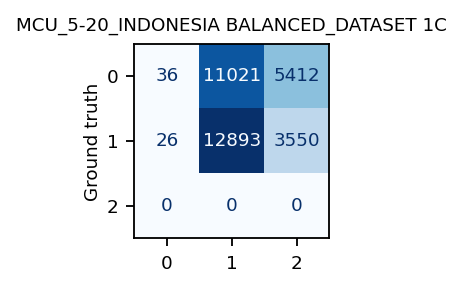

In [15]:
# -*- coding: utf-8 -*-
from Library import utils, dataset
import pandas as pd
import os
from tensorflow import keras
from tqdm import tqdm
import numpy as np
from datetime import datetime
import logging
import config

if __name__ == "__main__":
    #===================================================================
    # 1. KONFIGURASI DAN PEMETAAN DATA (SESUAI DATASET INDONESIA)
    #===================================================================
    source_to_code = {"noise": 0, "le": 1}
    code_to_source = {0: "noise", 1: "le"}
    true_labels = ["NO", "LE"]

    key_data_dir = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/"
    key_test_file = "master_catalog_balanced.json"
    
    # Path Model & Embedding (Pastikan path ini valid di sistem Anda)
    # Ganti format backslash (\) menjadi slash (/) dan gunakan path lengkap
    model_path = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
    embedding_3C_dir = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909"
    
    INPUT_WIN = 7 
    SAMPLING_RATE = 100
    MODEL_TAG = "MCU_5-20_INDONESIA"
    DATA_TAG = "BALANCED_DATASET"

    #===================================================================
    # 2. PERSIAPAN FILE & LOGGER (ALUR ZHI GENG)
    #===================================================================
    test_data = dataset.load_json_data(os.path.join(key_data_dir, key_test_file))
    NUM_RECORD = len(test_data)
    
    SAVE_BASE = f"{config.OUTPUT_PATH} benchmark metrics"
    now = datetime.now()
    time_str = now.strftime("%d%H%M%S")
    save_dir = os.path.join(SAVE_BASE, f"{MODEL_TAG} {DATA_TAG}, {time_str}")
    if not os.path.exists(save_dir): os.makedirs(save_dir)

    logging.basicConfig(filename=os.path.join(save_dir, "task log.txt"),
                        level=logging.INFO,
                        format='%(asctime)s - [%(levelname)s]: %(message)s',
                        filemode='w')
    logger = logging.getLogger()
    logger.addHandler(logging.StreamHandler())

    logger.info(f"Task summary: Dataset: {key_test_file}, Model: {MODEL_TAG}")

    # Load Model & Embeddings
    embedding_model = keras.models.load_model(filepath=model_path)
    
    # Kita gunakan Embedding Z saja sesuai dataset 1C Anda
    embedding_Z = dataset.load_embedding_data(embedding_3C_dir, "Embedding data, Z.json")
    embeddings_Z_PDFs = utils.embedding_PDFs_1D(embedding_Z)

    #===================================================================
    # 3. EVALUASI DAN INFERENSI (LOGIKA ZHI GENG)
    #===================================================================
    total_true_1C_KDE = []
    total_pred_1C_KDE = []
    
    num_points = int(INPUT_WIN * SAMPLING_RATE)
    keys_list = list(test_data.keys())[:NUM_RECORD]

    logger.info(f"Mulai inferensi untuk {len(keys_list)} sampel...")

    for i in tqdm(range(len(keys_list)), desc="Inferensi"):
        record_key = keys_list[i]
        record = test_data[record_key]
        quake_label = record["type"]
        
        # Load Z
        # Menggunakan np.load langsung dari path di JSON
        data_z = np.load(record["Z"])[:num_points]
        
        # Embed data (Latent Codes)
        _input_Z = utils.latent_codes_1D(data_z, embedding_model)
        
        # Inferensi 1C PDF (Menggunakan Kernel Density Estimation)
        _sources_code, _source_likelihood, _source_softmax = \
            utils.infer_1C_PDFs(_input_Z, embeddings_Z_PDFs, choose_pdf="Kernel")
        
        # Simpan hasil
        total_true_1C_KDE.append(source_to_code[quake_label])
        total_pred_1C_KDE.append(_sources_code)

    #===================================================================
    # 4. SIMPAN METRIK DAN VISUALISASI
    #===================================================================
    matrix_1C_KDE, metrics_1C_KDE = utils.calc_confusion_metrics(total_true_1C_KDE, total_pred_1C_KDE)
    
    fig = utils.plot_confusion(title=f"{MODEL_TAG} {DATA_TAG} 1C",
                               true_labels=true_labels,
                               matrix=matrix_1C_KDE,
                               metrics=metrics_1C_KDE,
                               fig_size=[6, 5])
    
    # Simpan hasil akhir
    fig.savefig(os.path.join(save_dir, "confusion_matrix.jpg"), dpi=300)
    dataset.save_json_data(os.path.join(save_dir, "metrics.json"), metrics_1C_KDE)
    
    logger.info("Tugas selesai. Metrik disimpan di: " + save_dir)

No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
Memulai inferensi untuk 32938 sampel...
Memulai inferensi untuk 32938 sampel...
Memulai inferensi untuk 32938 sampel...
Memulai inferensi untuk 32938 sampel...
Memulai inferensi untuk 32938 sampel...
Memulai inferensi untuk 32938 sampel...
Inferensi: 100%|██████████| 32938/32938 [02:02<00:00, 268.76it/s]
PPV: 0.5391, TPR: 0.9980, F1: 0.7001
PPV: 0.5391, TPR: 0.9980, F1: 0.7001
PPV: 0.5391, TPR: 0.

Accuracy: [0.5392475809142476, 0.5392475809142476]
Accuracy (avg.): 0.5392475809142476
True positive rate: [0.0032558560188116125, 0.9979874603297468]
True positive rate (avg.): 0.5392475809142476
True negative rate: [0.9979874603297468, 0.0032558560188116125]
True negative rate (avg.): 0.46199573543431094
Positive predictive value: [0.5806451612903226, 0.5391402525717153]
Positive predictive value (avg.): 0.5582810506907361
Negative predictive value: [0.5391402525717153, 0.5806451612903226]
Negative predictive value (avg.): 0.5615043631713019
False positive rate: [0.0020125396702531154, 0.9967441439811884]
False positive rate (avg.): 0.5380042645656891
False negative rate: [0.9967441439811884, 0.0020125396702531154]
False negative rate (avg.): 0.46075241908575243
False discovery rate: [0.41935483870967744, 0.46085974742828467]
False discovery rate (avg.): 0.441718949309264
F1-score: [0.006475402464250382, 0.7000787337441967]
F1-score (avg.): 0.3802100302923129

--- HASIL EVALUASI FINA

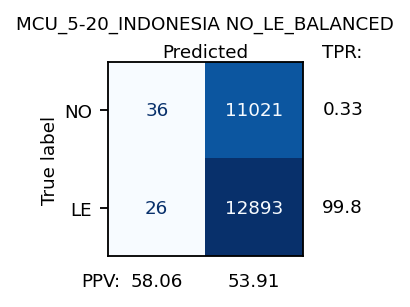

In [ ]:
# -*- coding: utf-8 -*-
from Library import utils, dataset
import os
import logging
from datetime import datetime
import numpy as np
from tensorflow import keras
from tqdm import tqdm
import config

if __name__ == "__main__":
    #===================================================================
    # 1. KONFIGURASI KELAS (NO & LE)
    #===================================================================
    source_to_code = {"noise": 0, "le": 1}
    code_to_source = {0: "noise", 1: "le"}
    true_labels = ["NO", "LE"]

    # Path absolut (macOS)
    key_data_dir = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output_01/"
    key_test_file = "master_catalog_balanced.json"
    model_path = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
    embedding_3C_dir = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909"
    
    INPUT_WIN = 7 
    SAMPLING_RATE = 100
    MODEL_TAG = "MCU_5-20_INDONESIA"
    DATA_TAG = "NO_LE_BALANCED"

    #===================================================================
    # 2. INISIALISASI LOGGER
    #===================================================================
    save_dir = os.path.join(f"{config.OUTPUT_PATH} benchmark metrics", f"{MODEL_TAG}_{DATA_TAG}_{datetime.now().strftime('%d%H%M%S')}")
    os.makedirs(save_dir, exist_ok=True)
    logging.basicConfig(filename=os.path.join(save_dir, "task_log.txt"), level=logging.INFO, filemode='w')
    logger = logging.getLogger()
    logger.addHandler(logging.StreamHandler())

    # Load Model & Embedding
    embedding_model = keras.models.load_model(filepath=model_path)
    embedding_Z = dataset.load_embedding_data(embedding_3C_dir, "Embedding data, Z.json")
    embeddings_Z_PDFs = utils.embedding_PDFs_1D(embedding_Z)

    #===================================================================
    # 3. INFERENSI
    #===================================================================
    test_data = dataset.load_json_data(os.path.join(key_data_dir, key_test_file))
    total_true, total_pred = [], []
    num_points = int(INPUT_WIN * SAMPLING_RATE)

    logger.info(f"Memulai inferensi untuk {len(test_data)} sampel...")

    for record_key, record in tqdm(test_data.items(), desc="Inferensi"):
        # Load Z
        data_z = np.load(record["Z"])[:num_points]
        
        # Ekstraksi Latent Codes
        _input_Z = utils.latent_codes_1D(data_z, embedding_model)
        
        # Inferensi Kernel Density Estimation
        _sources_code, _, _ = utils.infer_1C_PDFs(_input_Z, embeddings_Z_PDFs, choose_pdf="Kernel")
        
        # Simpan jika kelas valid (0=NO, 1=LE)
        if _sources_code < 2:
            total_true.append(source_to_code[record["type"]])
            total_pred.append(_sources_code)

    #===================================================================
    # 4. EVALUASI DAN METRIK (PPV & TPR)
    #===================================================================
    matrix, metrics = utils.calc_confusion_metrics(total_true, total_pred)
    
    # Ekstraksi PPV & TPR secara manual dari matrix [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = matrix.ravel()
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (ppv * tpr) / (ppv + tpr) if (ppv + tpr) > 0 else 0

    print(f"\n--- HASIL EVALUASI FINAL ---")
    print(f"Precision (PPV): {ppv:.4f}")
    print(f"Recall (TPR)   : {tpr:.4f}")
    print(f"F1-Score       : {f1:.4f}")
    
    logger.info(f"PPV: {ppv:.4f}, TPR: {tpr:.4f}, F1: {f1:.4f}")

    # Plot & Save
    fig = utils.plot_confusion(title=f"{MODEL_TAG} {DATA_TAG}",
                               true_labels=true_labels,
                               matrix=matrix,
                               metrics=metrics,
                               fig_size=[6, 5])
    
    fig.savefig(os.path.join(save_dir, "confusion_matrix.jpg"), dpi=300)
    dataset.save_json_data(os.path.join(save_dir, "metrics.json"), metrics)
    
    logger.info(f"Hasil lengkap disimpan di: {save_dir}")

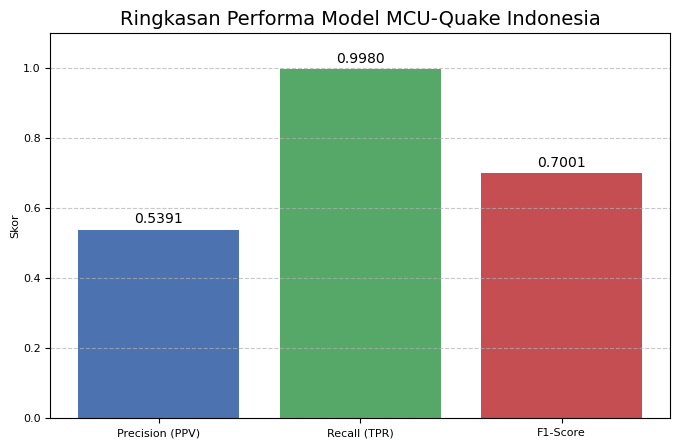

In [19]:
import matplotlib.pyplot as plt

# Data Metrik Final
metrics = ['Precision (PPV)', 'Recall (TPR)', 'F1-Score']
values = [0.5391, 0.9980, 0.7001]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values, color=['#4C72B0', '#55A868', '#C44E52'])

# Menambahkan label angka di atas batang
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')

plt.title('Ringkasan Performa Model MCU-Quake Indonesia', fontsize=14)
plt.ylabel('Skor')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

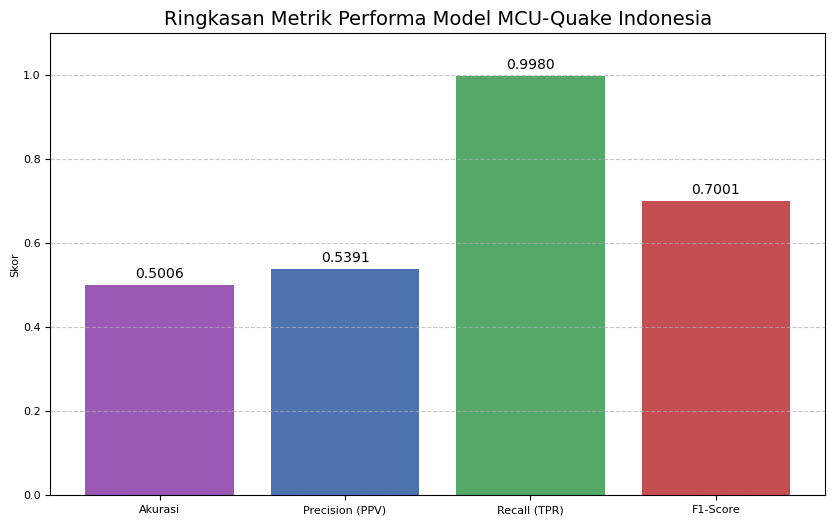

In [21]:
import matplotlib.pyplot as plt

# Data Metrik Final
metrics = ['Akurasi', 'Precision (PPV)', 'Recall (TPR)', 'F1-Score']
values = [0.5006, 0.5391, 0.9980, 0.7001]

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['#9B59B6', '#4C72B0', '#55A868', '#C44E52'])

# Menambahkan label angka di atas batang
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')

plt.title('Ringkasan Metrik Performa Model MCU-Quake Indonesia', fontsize=14)
plt.ylabel('Skor')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()